# VSD Exclusion Validation: Subjects 010, 015, 017

This notebook validates whether the VSD multifolder subjects `010`, `015`, and `017` should remain excluded, or whether merging their lower-leg and upper-leg DICOM folders makes them usable for knee cropping.

The specific question being tested is whether the earlier exclusion of `010` and `017` was caused by an incorrect z-coverage estimate from lexicographically sorted DICOM filenames rather than physical slice positions.

## Success Criteria

A multifolder subject is considered usable in this exploratory validation if:

1. The merged upper/lower physical z-span is at least `700mm`.
2. The internal gap between adjacent lower/upper folders is at most `5mm`.
3. The merged bone cross-section profile has a detected knee peak in the expected lower-limb zone, `40-65%` of the merged z-span.
4. The merged anatomy visuals show a continuous lower-limb volume after ordering slices by physical z-position.

Assumptions:

- The current workspace data is authoritative.
- The current raw tree contains the direct B30s upper/lower folders for these subjects.
- This notebook is exploratory validation only; it does not change preprocessing package code or reference notebooks.

## 1 - Imports and Configuration

In [1]:
from pathlib import Path
import gc

import numpy as np
import pydicom
import SimpleITK as sitk
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks

try:
    import pandas as pd
except ImportError:
    pd = None

try:
    from IPython.display import display
except ImportError:
    display = print

PROJECT_ROOT = Path(r"C:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\TestProject\TestProject")
VSD_ROOT = PROJECT_ROOT / "data" / "raw" / "VSD_Dataset"

SUBJECTS = ["010", "015", "016", "017", "019"]
BONE_HU_THRESHOLD = 200
KNEE_Z_RANGE = (0.40, 0.65)
MIN_Z_EXTENT_MM = 700
MAX_ALLOWED_GAP_MM = 5
KNEE_VISUAL_OFFSETS_MM = [-100, -50, 0, 50, 100]
HU_WINDOW = (-450, 1050)

print(f"VSD root: {VSD_ROOT}")
print(f"Subjects: {SUBJECTS}")
print(f"pandas available: {pd is not None}")

VSD root: C:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\TestProject\TestProject\data\raw\VSD_Dataset
Subjects: ['010', '015', '016', '017', '019']
pandas available: True


## 2 - Helper Functions

The old failure mode is reproduced intentionally by taking the first and last files after normal lexicographic filename sorting. This is not physically meaningful for DICOM files named like `...1.dcm`, `...10.dcm`, `...100.dcm`, ..., `...99.dcm`.

The corrected method reads every slice position from `ImagePositionPatient[2]` and uses the physical minimum and maximum z-coordinate.

In [2]:
def classify_region(series_description):
    desc = str(series_description).lower()
    if "upper" in desc or "unt.extr.os" in desc:
        return "upper_leg"
    if "lower" in desc or "unt.extr.us" in desc:
        return "lower_leg"
    return "unknown"


def read_dicom_z(path):
    ds = pydicom.dcmread(str(path), stop_before_pixels=True)
    return float(ds.ImagePositionPatient[2]), ds


def inspect_series_folder(series_dir):
    dcm_files = sorted(series_dir.glob("*.dcm"))
    if not dcm_files:
        raise FileNotFoundError(f"No DICOM files found in {series_dir}")

    old_z_first, first_ds = read_dicom_z(dcm_files[0])
    old_z_last, _ = read_dicom_z(dcm_files[-1])
    old_z_min = min(old_z_first, old_z_last)
    old_z_max = max(old_z_first, old_z_last)

    z_positions = []
    for dcm_file in dcm_files:
        z, _ = read_dicom_z(dcm_file)
        z_positions.append(z)

    z_positions = np.array(z_positions, dtype=float)
    series_description = str(getattr(first_ds, "SeriesDescription", "N/A"))
    kernel = str(getattr(first_ds, "ConvolutionKernel", "N/A"))

    return {
        "subject": series_dir.parent.name,
        "smir_id": series_dir.name.split(".")[-1],
        "series_dir": series_dir,
        "series": series_description,
        "kernel": kernel,
        "region": classify_region(series_description),
        "n_slices": len(dcm_files),
        "lex_first_file": dcm_files[0].name,
        "lex_last_file": dcm_files[-1].name,
        "old_z_min_mm": old_z_min,
        "old_z_max_mm": old_z_max,
        "old_z_span_mm": old_z_max - old_z_min,
        "true_z_min_mm": float(z_positions.min()),
        "true_z_max_mm": float(z_positions.max()),
        "true_z_span_mm": float(z_positions.max() - z_positions.min()),
        "z_positions": z_positions,
    }


def load_series_array_and_z(series_dir):
    reader = sitk.ImageSeriesReader()
    dicom_names = list(reader.GetGDCMSeriesFileNames(str(series_dir)))
    if not dicom_names:
        raise FileNotFoundError(f"SimpleITK found no DICOM files in {series_dir}")

    reader.SetFileNames(dicom_names)
    img = reader.Execute()
    arr = sitk.GetArrayFromImage(img)

    z_positions = []
    for dcm_name in dicom_names:
        ds = pydicom.dcmread(str(dcm_name), stop_before_pixels=True)
        z_positions.append(float(ds.ImagePositionPatient[2]))

    del img
    gc.collect()
    return np.array(z_positions, dtype=float), arr


def load_bone_profile(series_dir):
    z_positions, arr = load_series_array_and_z(series_dir)
    bone_area = (arr > BONE_HU_THRESHOLD).sum(axis=(1, 2)).astype(float)
    del arr
    gc.collect()
    return z_positions, bone_area


def analyze_bone_profile(z_positions, bone_area):
    order = np.argsort(z_positions)
    z_sorted = z_positions[order]
    bone_sorted = bone_area[order]
    rel_z_mm = z_sorted - z_sorted.min()
    total_z_mm = float(rel_z_mm.max())
    smoothed = gaussian_filter1d(bone_sorted, sigma=20)

    if smoothed.max() > 0:
        peaks, _ = find_peaks(
            smoothed,
            height=smoothed.max() * 0.20,
            distance=80,
            prominence=smoothed.max() * 0.05,
        )
    else:
        peaks = np.array([], dtype=int)

    knee_low = total_z_mm * KNEE_Z_RANGE[0]
    knee_high = total_z_mm * KNEE_Z_RANGE[1]
    knee_candidates = [p for p in peaks if knee_low <= rel_z_mm[p] <= knee_high]
    best_peak = max(knee_candidates, key=lambda p: smoothed[p]) if knee_candidates else None

    return {
        "rel_z_mm": rel_z_mm,
        "bone_area": bone_sorted,
        "smoothed": smoothed,
        "peaks": peaks,
        "knee_candidates": knee_candidates,
        "best_peak": best_peak,
        "total_z_mm": total_z_mm,
        "knee_low_mm": knee_low,
        "knee_high_mm": knee_high,
    }


def maybe_round(value, digits=1):
    if isinstance(value, (float, np.floating)):
        return round(float(value), digits)
    if isinstance(value, list):
        return [maybe_round(item, digits) for item in value]
    return value


def show_table(rows, columns=None, digits=1):
    selected = []
    for row in rows:
        if columns is None:
            out = dict(row)
        else:
            out = {col: row.get(col) for col in columns}
        selected.append({key: maybe_round(value, digits) for key, value in out.items()})

    if pd is not None:
        table = pd.DataFrame(selected)
        display(table)
        return table

    for row in selected:
        print(row)
    return selected


def records_for_subject(rows, subject_id):
    return [row for row in rows if row["subject"] == subject_id]


def merge_ranges_for_subject(rows, subject_id):
    sub = records_for_subject(rows, subject_id)
    ranges = sorted(
        [
            (row["true_z_min_mm"], row["true_z_max_mm"], row["smir_id"], row["region"])
            for row in sub
        ],
        key=lambda item: item[0],
    )
    gaps = [ranges[i + 1][0] - ranges[i][1] for i in range(len(ranges) - 1)]
    return ranges, gaps


def selected_profile_for_subject(profile_rows, subject_id):
    return next(row for row in profile_rows if row["subject"] == subject_id)

## 3 - DICOM Folder Inventory

In [3]:
records = []
for subject_id in SUBJECTS:
    subject_dir = VSD_ROOT / subject_id
    for series_dir in sorted([p for p in subject_dir.iterdir() if p.is_dir()]):
        records.append(inspect_series_folder(series_dir))

inventory_cols = [
    "subject", "smir_id", "series", "kernel", "region", "n_slices",
    "true_z_min_mm", "true_z_max_mm", "true_z_span_mm",
]
show_table(records, inventory_cols)

print("Folders discovered per subject:")
folder_rows = [
    {"subject": subject_id, "smir_ids": [row["smir_id"] for row in records_for_subject(records, subject_id)]}
    for subject_id in SUBJECTS
]
show_table(folder_rows)

,subject,smir_id,series,kernel,region,n_slices,true_z_min_mm,true_z_max_mm,true_z_span_mm
0,010,265,Unt.Extr.OS 1.25 B30s,B30s,upper_leg,997,696.4,1294.0,597.6
1,010,268,Unt.Extr.US 1.25 B30s,B30s,lower_leg,763,238.8,696.0,457.2
2,015,453,Lower leg 1.25 B30s,B30s,lower_leg,831,-94.5,403.5,498.0
3,015,455,Upper leg 1.25 B30s,B30s,upper_leg,1074,403.7,1047.5,643.8
4,016,476,Upper leg 1.25 B30s,B30s,upper_leg,1056,467.0,1100.0,633.0
5,016,481,Lower leg 1.25 B30s,B30s,lower_leg,722,33.9,466.5,432.6
6,017,487,Upper leg 1.25 B30s,B30s,upper_leg,1020,469.6,1081.0,611.4
7,017,490,Lower leg 1.25 B30s,B30s,lower_leg,849,-39.3,469.5,508.8
8,019,495,Upper leg 1.25 B30s,B30s,upper_leg,1051,393.0,1023.0,630.0
9,019,497,Lower leg 1.25 B30s,B30s,lower_leg,844,-113.3,392.5,505.8


Folders discovered per subject:


,subject,smir_ids
0,010,"[265, 268]"
1,015,"[453, 455]"
2,016,"[476, 481]"
3,017,"[487, 490]"
4,019,"[495, 497]"


,subject,smir_ids
0,010,"[265, 268]"
1,015,"[453, 455]"
2,016,"[476, 481]"
3,017,"[487, 490]"
4,019,"[495, 497]"


## 4 - Reproduce the Old Lexicographic z-Range Bug

The previous folder comparison underestimated lower-leg coverage because lexicographic filename sorting places `100.dcm` near the beginning and `99.dcm` near the end. For lower-leg folders, those two files are physically close to the upper boundary, so the apparent z-span becomes about `59mm` even though the folder contains hundreds of slices.

In [4]:
bug_cols = [
    "subject", "smir_id", "region", "n_slices",
    "lex_first_file", "lex_last_file",
    "old_z_min_mm", "old_z_max_mm", "old_z_span_mm",
    "true_z_min_mm", "true_z_max_mm", "true_z_span_mm",
]

bug_rows = []
for row in records:
    bug_row = {col: row[col] for col in bug_cols}
    bug_row["span_error_mm"] = row["true_z_span_mm"] - row["old_z_span_mm"]
    bug_rows.append(bug_row)
show_table(bug_rows)

lower_bug_cols = ["subject", "smir_id", "old_z_span_mm", "true_z_span_mm", "span_error_mm"]
lower_bug = [row for row in bug_rows if row["region"] == "lower_leg"]
show_table(lower_bug, lower_bug_cols)

,subject,smir_id,region,n_slices,lex_first_file,lex_last_file,old_z_min_mm,old_z_max_mm,old_z_span_mm,true_z_min_mm,true_z_max_mm,true_z_span_mm,span_error_mm
0,010,265,upper_leg,997,SMIR.Lower_limb.045Y.F.CT.265.1.dcm,SMIR.Lower_limb.045Y.F.CT.265.997.dcm,696.4,1294.0,597.6,696.4,1294.0,597.6,0.0
1,010,268,lower_leg,763,SMIR.Lower_limb.045Y.F.CT.268.1.dcm,SMIR.Lower_limb.045Y.F.CT.268.99.dcm,637.2,696.0,58.8,238.8,696.0,457.2,398.4
2,015,453,lower_leg,831,SMIR.Lower_limb.081Y.M.CT.453.1.dcm,SMIR.Lower_limb.081Y.M.CT.453.99.dcm,344.7,403.5,58.8,-94.5,403.5,498.0,439.2
3,015,455,upper_leg,1074,SMIR.Lower_limb.081Y.M.CT.455.1.dcm,SMIR.Lower_limb.081Y.M.CT.455.999.dcm,448.7,1047.5,598.8,403.7,1047.5,643.8,45.0
4,016,476,upper_leg,1056,SMIR.Lower_limb.095Y.F.CT.476.1.dcm,SMIR.Lower_limb.095Y.F.CT.476.999.dcm,501.2,1100.0,598.8,467.0,1100.0,633.0,34.2
5,016,481,lower_leg,722,SMIR.Lower_limb.095Y.F.CT.481.1.dcm,SMIR.Lower_limb.095Y.F.CT.481.99.dcm,407.7,466.5,58.8,33.9,466.5,432.6,373.8
6,017,487,upper_leg,1020,SMIR.Lower_limb.019Y.F.CT.487.1.dcm,SMIR.Lower_limb.019Y.F.CT.487.999.dcm,482.2,1081.0,598.8,469.6,1081.0,611.4,12.6
7,017,490,lower_leg,849,SMIR.Lower_limb.019Y.F.CT.490.1.dcm,SMIR.Lower_limb.019Y.F.CT.490.99.dcm,410.7,469.5,58.8,-39.3,469.5,508.8,450.0
8,019,495,upper_leg,1051,SMIR.Lower_limb.056Y.M.CT.495.1.dcm,SMIR.Lower_limb.056Y.M.CT.495.999.dcm,424.2,1023.0,598.8,393.0,1023.0,630.0,31.2
9,019,497,lower_leg,844,SMIR.Lower_limb.056Y.M.CT.497.1.dcm,SMIR.Lower_limb.056Y.M.CT.497.99.dcm,333.7,392.5,58.8,-113.3,392.5,505.8,447.0


,subject,smir_id,old_z_span_mm,true_z_span_mm,span_error_mm
0,010,268,58.8,457.2,398.4
1,015,453,58.8,498.0,439.2
2,016,481,58.8,432.6,373.8
3,017,490,58.8,508.8,450.0
4,019,497,58.8,505.8,447.0


,subject,smir_id,old_z_span_mm,true_z_span_mm,span_error_mm
0,010,268,58.8,457.2,398.4
1,015,453,58.8,498.0,439.2
2,016,481,58.8,432.6,373.8
3,017,490,58.8,508.8,450.0
4,019,497,58.8,505.8,447.0


## 5 - Correct Merged Physical Coverage

This step merges each subject virtually by physical z-coordinate. It does not write a merged volume; it only checks whether the two series cover a contiguous lower-limb scan.

In [5]:
merge_rows = []

for subject_id in SUBJECTS:
    ranges, gaps = merge_ranges_for_subject(records, subject_id)
    merged_z_min = min(r[0] for r in ranges)
    merged_z_max = max(r[1] for r in ranges)
    merged_span = merged_z_max - merged_z_min
    max_gap = max(gaps) if gaps else 0.0

    merge_rows.append({
        "subject": subject_id,
        "ordered_folders_low_to_high_z": " + ".join(f"{smir_id} ({region})" for _, _, smir_id, region in ranges),
        "merged_z_min_mm": merged_z_min,
        "merged_z_max_mm": merged_z_max,
        "merged_span_mm": merged_span,
        "internal_gaps_mm": [round(float(g), 1) for g in gaps],
        "max_gap_mm": max_gap,
        "passes_span_check": merged_span >= MIN_Z_EXTENT_MM,
        "passes_gap_check": max_gap <= MAX_ALLOWED_GAP_MM,
    })

show_table(merge_rows)

,subject,ordered_folders_low_to_high_z,merged_z_min_mm,merged_z_max_mm,merged_span_mm,internal_gaps_mm,max_gap_mm,passes_span_check,passes_gap_check
0,010,268 (lower_leg) + 265 (upper_leg),238.8,1294.0,1055.2,[0.4],0.4,True,True
1,015,453 (lower_leg) + 455 (upper_leg),-94.5,1047.5,1142.0,[0.2],0.2,True,True
2,016,481 (lower_leg) + 476 (upper_leg),33.9,1100.0,1066.1,[0.5],0.5,True,True
3,017,490 (lower_leg) + 487 (upper_leg),-39.3,1081.0,1120.3,[0.1],0.1,True,True
4,019,497 (lower_leg) + 495 (upper_leg),-113.3,1023.0,1136.3,[0.5],0.5,True,True


,subject,ordered_folders_low_to_high_z,merged_z_min_mm,merged_z_max_mm,merged_span_mm,internal_gaps_mm,max_gap_mm,passes_span_check,passes_gap_check
0,010,268 (lower_leg) + 265 (upper_leg),238.8,1294.0,1055.2,[0.4],0.4,True,True
1,015,453 (lower_leg) + 455 (upper_leg),-94.5,1047.5,1142.0,[0.2],0.2,True,True
2,016,481 (lower_leg) + 476 (upper_leg),33.9,1100.0,1066.1,[0.5],0.5,True,True
3,017,490 (lower_leg) + 487 (upper_leg),-39.3,1081.0,1120.3,[0.1],0.1,True,True
4,019,497 (lower_leg) + 495 (upper_leg),-113.3,1023.0,1136.3,[0.5],0.5,True,True


## 6 - Merged Bone Profile Validation

The final check loads the actual voxel data for each upper/lower series, computes per-slice bone area with `HU > 200`, concatenates both folders by physical z-position, and checks for the expected knee peak.

Loading subject 010...
  ID=268 lower_leg B30s: 763 slices, z=[238.8, 696.0]mm
  ID=265 upper_leg B30s: 997 slices, z=[696.4, 1294.0]mm
Loading subject 015...
  ID=453 lower_leg B30s: 831 slices, z=[-94.5, 403.5]mm
  ID=455 upper_leg B30s: 1074 slices, z=[403.7, 1047.5]mm
Loading subject 016...
  ID=481 lower_leg B30s: 722 slices, z=[33.9, 466.5]mm
  ID=476 upper_leg B30s: 1056 slices, z=[467.0, 1100.0]mm
Loading subject 017...
  ID=490 lower_leg B30s: 849 slices, z=[-39.3, 469.5]mm
  ID=487 upper_leg B30s: 1020 slices, z=[469.6, 1081.0]mm
Loading subject 019...
  ID=497 lower_leg B30s: 844 slices, z=[-113.3, 392.5]mm
  ID=495 upper_leg B30s: 1051 slices, z=[393.0, 1023.0]mm


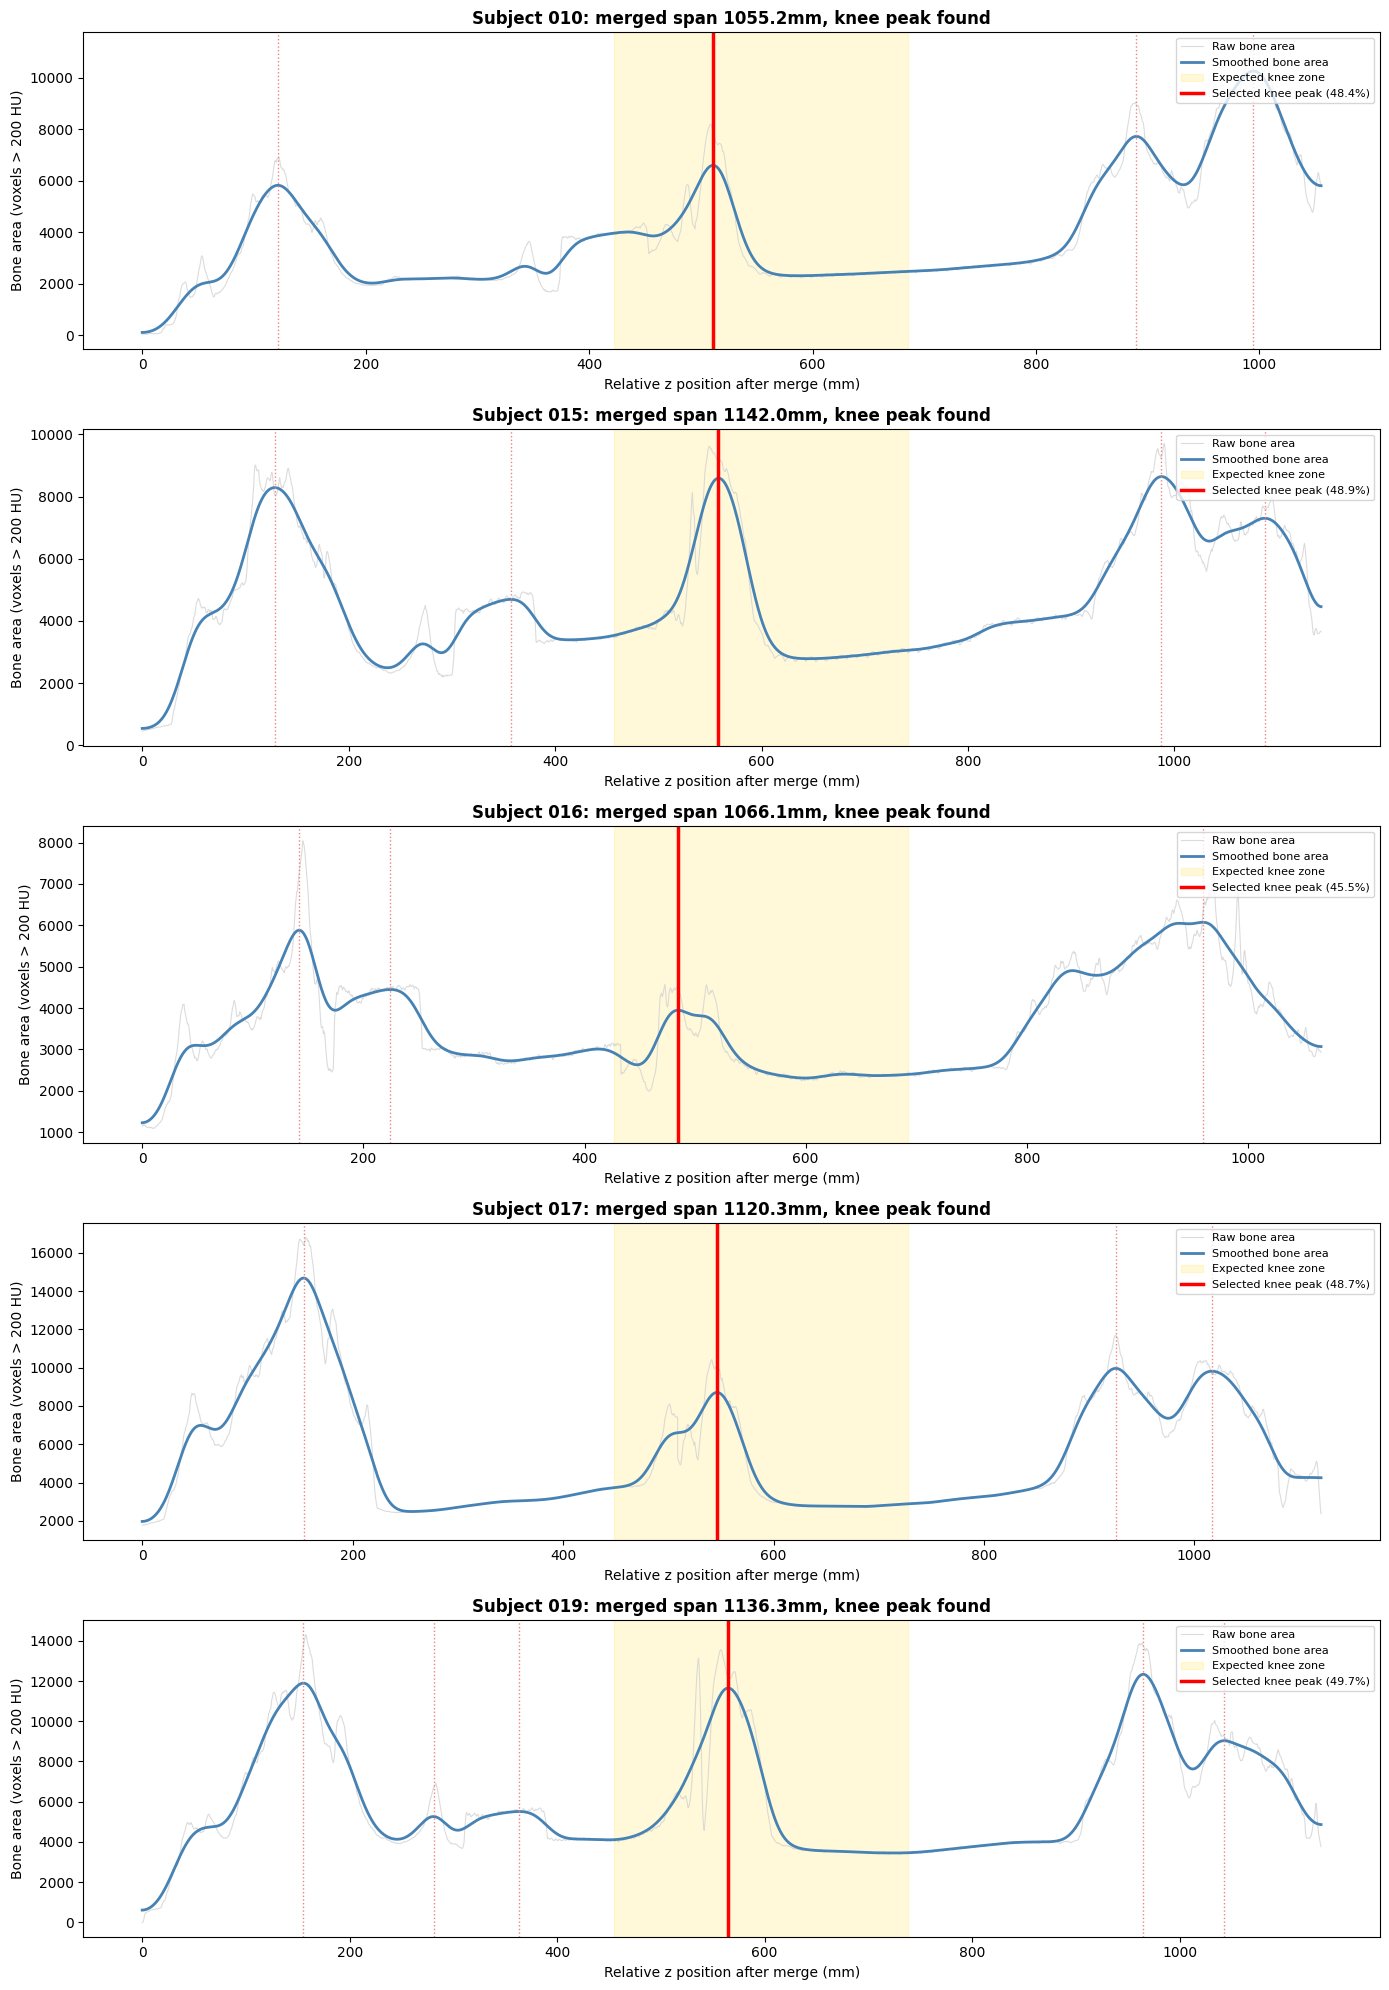

,subject,merged_span_mm,detected_peak_z_mm,has_expected_zone_knee_peak,selected_knee_z_mm,selected_knee_pct
0,010,1055.2,"[121.2, 511.0, 889.6, 994.6]",True,511.0,48.4
1,015,1142.0,"[128.4, 357.0, 558.2, 987.2, 1087.4]",True,558.2,48.9
2,016,1066.1,"[142.2, 224.4, 484.7, 959.3]",True,484.7,45.5
3,017,1120.3,"[153.6, 546.1, 925.3, 1016.5]",True,546.1,48.7
4,019,1136.3,"[155.4, 280.8, 363.0, 565.1, 964.7, 1042.7]",True,565.1,49.7


,subject,merged_span_mm,detected_peak_z_mm,has_expected_zone_knee_peak,selected_knee_z_mm,selected_knee_pct
0,010,1055.2,"[121.2, 511.0, 889.6, 994.6]",True,511.0,48.4
1,015,1142.0,"[128.4, 357.0, 558.2, 987.2, 1087.4]",True,558.2,48.9
2,016,1066.1,"[142.2, 224.4, 484.7, 959.3]",True,484.7,45.5
3,017,1120.3,"[153.6, 546.1, 925.3, 1016.5]",True,546.1,48.7
4,019,1136.3,"[155.4, 280.8, 363.0, 565.1, 964.7, 1042.7]",True,565.1,49.7


In [6]:
profile_rows = []
profile_results = {}

fig, axes = plt.subplots(len(SUBJECTS), 1, figsize=(14, 4 * len(SUBJECTS)), sharex=False)
if len(SUBJECTS) == 1:
    axes = [axes]

for ax, subject_id in zip(axes, SUBJECTS):
    sub = sorted(records_for_subject(records, subject_id), key=lambda row: row["true_z_min_mm"])
    z_parts = []
    bone_parts = []

    print(f"Loading subject {subject_id}...")
    for row in sub:
        z_positions, bone_area = load_bone_profile(row["series_dir"])
        z_parts.append(z_positions)
        bone_parts.append(bone_area)
        print(
            f"  ID={row['smir_id']} {row['region']} {row['kernel']}: "
            f"{len(bone_area)} slices, z=[{z_positions.min():.1f}, {z_positions.max():.1f}]mm"
        )

    merged_z = np.concatenate(z_parts)
    merged_bone = np.concatenate(bone_parts)
    result = analyze_bone_profile(merged_z, merged_bone)
    profile_results[subject_id] = result

    rel_z = result["rel_z_mm"]
    smoothed = result["smoothed"]
    peaks = result["peaks"]
    best_peak = result["best_peak"]
    has_knee_peak = best_peak is not None

    peak_positions = [round(float(rel_z[p]), 1) for p in peaks]
    knee_z_mm = round(float(rel_z[best_peak]), 1) if has_knee_peak else None
    knee_pct = round(knee_z_mm / result["total_z_mm"] * 100, 1) if has_knee_peak else None

    profile_rows.append({
        "subject": subject_id,
        "merged_span_mm": result["total_z_mm"],
        "detected_peak_z_mm": peak_positions,
        "has_expected_zone_knee_peak": has_knee_peak,
        "selected_knee_z_mm": knee_z_mm,
        "selected_knee_pct": knee_pct,
    })

    ax.plot(rel_z, result["bone_area"], color="lightgray", linewidth=0.8, alpha=0.8, label="Raw bone area")
    ax.plot(rel_z, smoothed, color="steelblue", linewidth=2, label="Smoothed bone area")
    ax.axvspan(result["knee_low_mm"], result["knee_high_mm"], color="gold", alpha=0.15, label="Expected knee zone")

    for peak in peaks:
        ax.axvline(rel_z[peak], color="lightcoral", linestyle=":", linewidth=1)

    if has_knee_peak:
        ax.axvline(rel_z[best_peak], color="red", linewidth=2.5, label=f"Selected knee peak ({knee_pct:.1f}%)")

    ax.set_title(
        f"Subject {subject_id}: merged span {result['total_z_mm']:.1f}mm, "
        f"knee peak {'found' if has_knee_peak else 'not found'}",
        fontweight="bold",
    )
    ax.set_xlabel("Relative z position after merge (mm)")
    ax.set_ylabel("Bone area (voxels > 200 HU)")
    ax.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

show_table(profile_rows)

## 7 - Merged Anatomy Visuals

These figures show the actual CT anatomy after lower and upper folders are virtually merged by physical z-position.

- The first figure shows a merged coronal and sagittal view for each subject.
- The dashed cyan line marks the lower/upper folder boundary.
- The red line marks the selected knee center from the merged bone profile.
- Green lines mark the planned `+/-100mm` crop margin around the knee.
- The second figure shows axial slices centered around the detected knee.

In [7]:
def collect_merged_visual_views(subject_id, records, profile_row):
    sub = sorted(records_for_subject(records, subject_id), key=lambda row: row["true_z_min_mm"])
    merged_z_min = min(row["true_z_min_mm"] for row in sub)
    merged_z_max = max(row["true_z_max_mm"] for row in sub)
    selected_knee_rel = float(profile_row["selected_knee_z_mm"])
    selected_knee_abs = merged_z_min + selected_knee_rel
    target_abs_z = {
        offset: selected_knee_abs + offset
        for offset in KNEE_VISUAL_OFFSETS_MM
    }

    coronal_parts = []
    sagittal_parts = []
    boundary_rel_z = []
    axial_best = {
        offset: {"delta": np.inf, "slice": None, "actual_z": None}
        for offset in KNEE_VISUAL_OFFSETS_MM
    }

    for part_idx, row in enumerate(sub):
        z_positions, arr = load_series_array_and_z(row["series_dir"])
        order = np.argsort(z_positions)
        z_sorted = z_positions[order]
        arr_sorted = arr[order]

        mid_y = arr_sorted.shape[1] // 2
        mid_x = arr_sorted.shape[2] // 2
        coronal_parts.append(arr_sorted[:, mid_y, :])
        sagittal_parts.append(arr_sorted[:, :, mid_x])

        for offset, abs_z in target_abs_z.items():
            nearest_idx = int(np.argmin(np.abs(z_sorted - abs_z)))
            delta = abs(float(z_sorted[nearest_idx]) - abs_z)
            if delta < axial_best[offset]["delta"]:
                axial_best[offset] = {
                    "delta": delta,
                    "slice": arr_sorted[nearest_idx].copy(),
                    "actual_z": float(z_sorted[nearest_idx]),
                }

        if part_idx < len(sub) - 1:
            boundary_rel_z.append(row["true_z_max_mm"] - merged_z_min)

        del arr, arr_sorted
        gc.collect()

    return {
        "subject": subject_id,
        "coronal": np.vstack(coronal_parts),
        "sagittal": np.vstack(sagittal_parts),
        "axial_best": axial_best,
        "merged_span_mm": merged_z_max - merged_z_min,
        "knee_rel_z_mm": selected_knee_rel,
        "boundary_rel_z_mm": boundary_rel_z,
    }


visual_results = []
for subject_id in SUBJECTS:
    print(f"Collecting merged anatomy views for subject {subject_id}...")
    profile_row = selected_profile_for_subject(profile_rows, subject_id)
    visual_results.append(collect_merged_visual_views(subject_id, records, profile_row))

print("Merged anatomy views collected.")

Merged anatomy views collected.


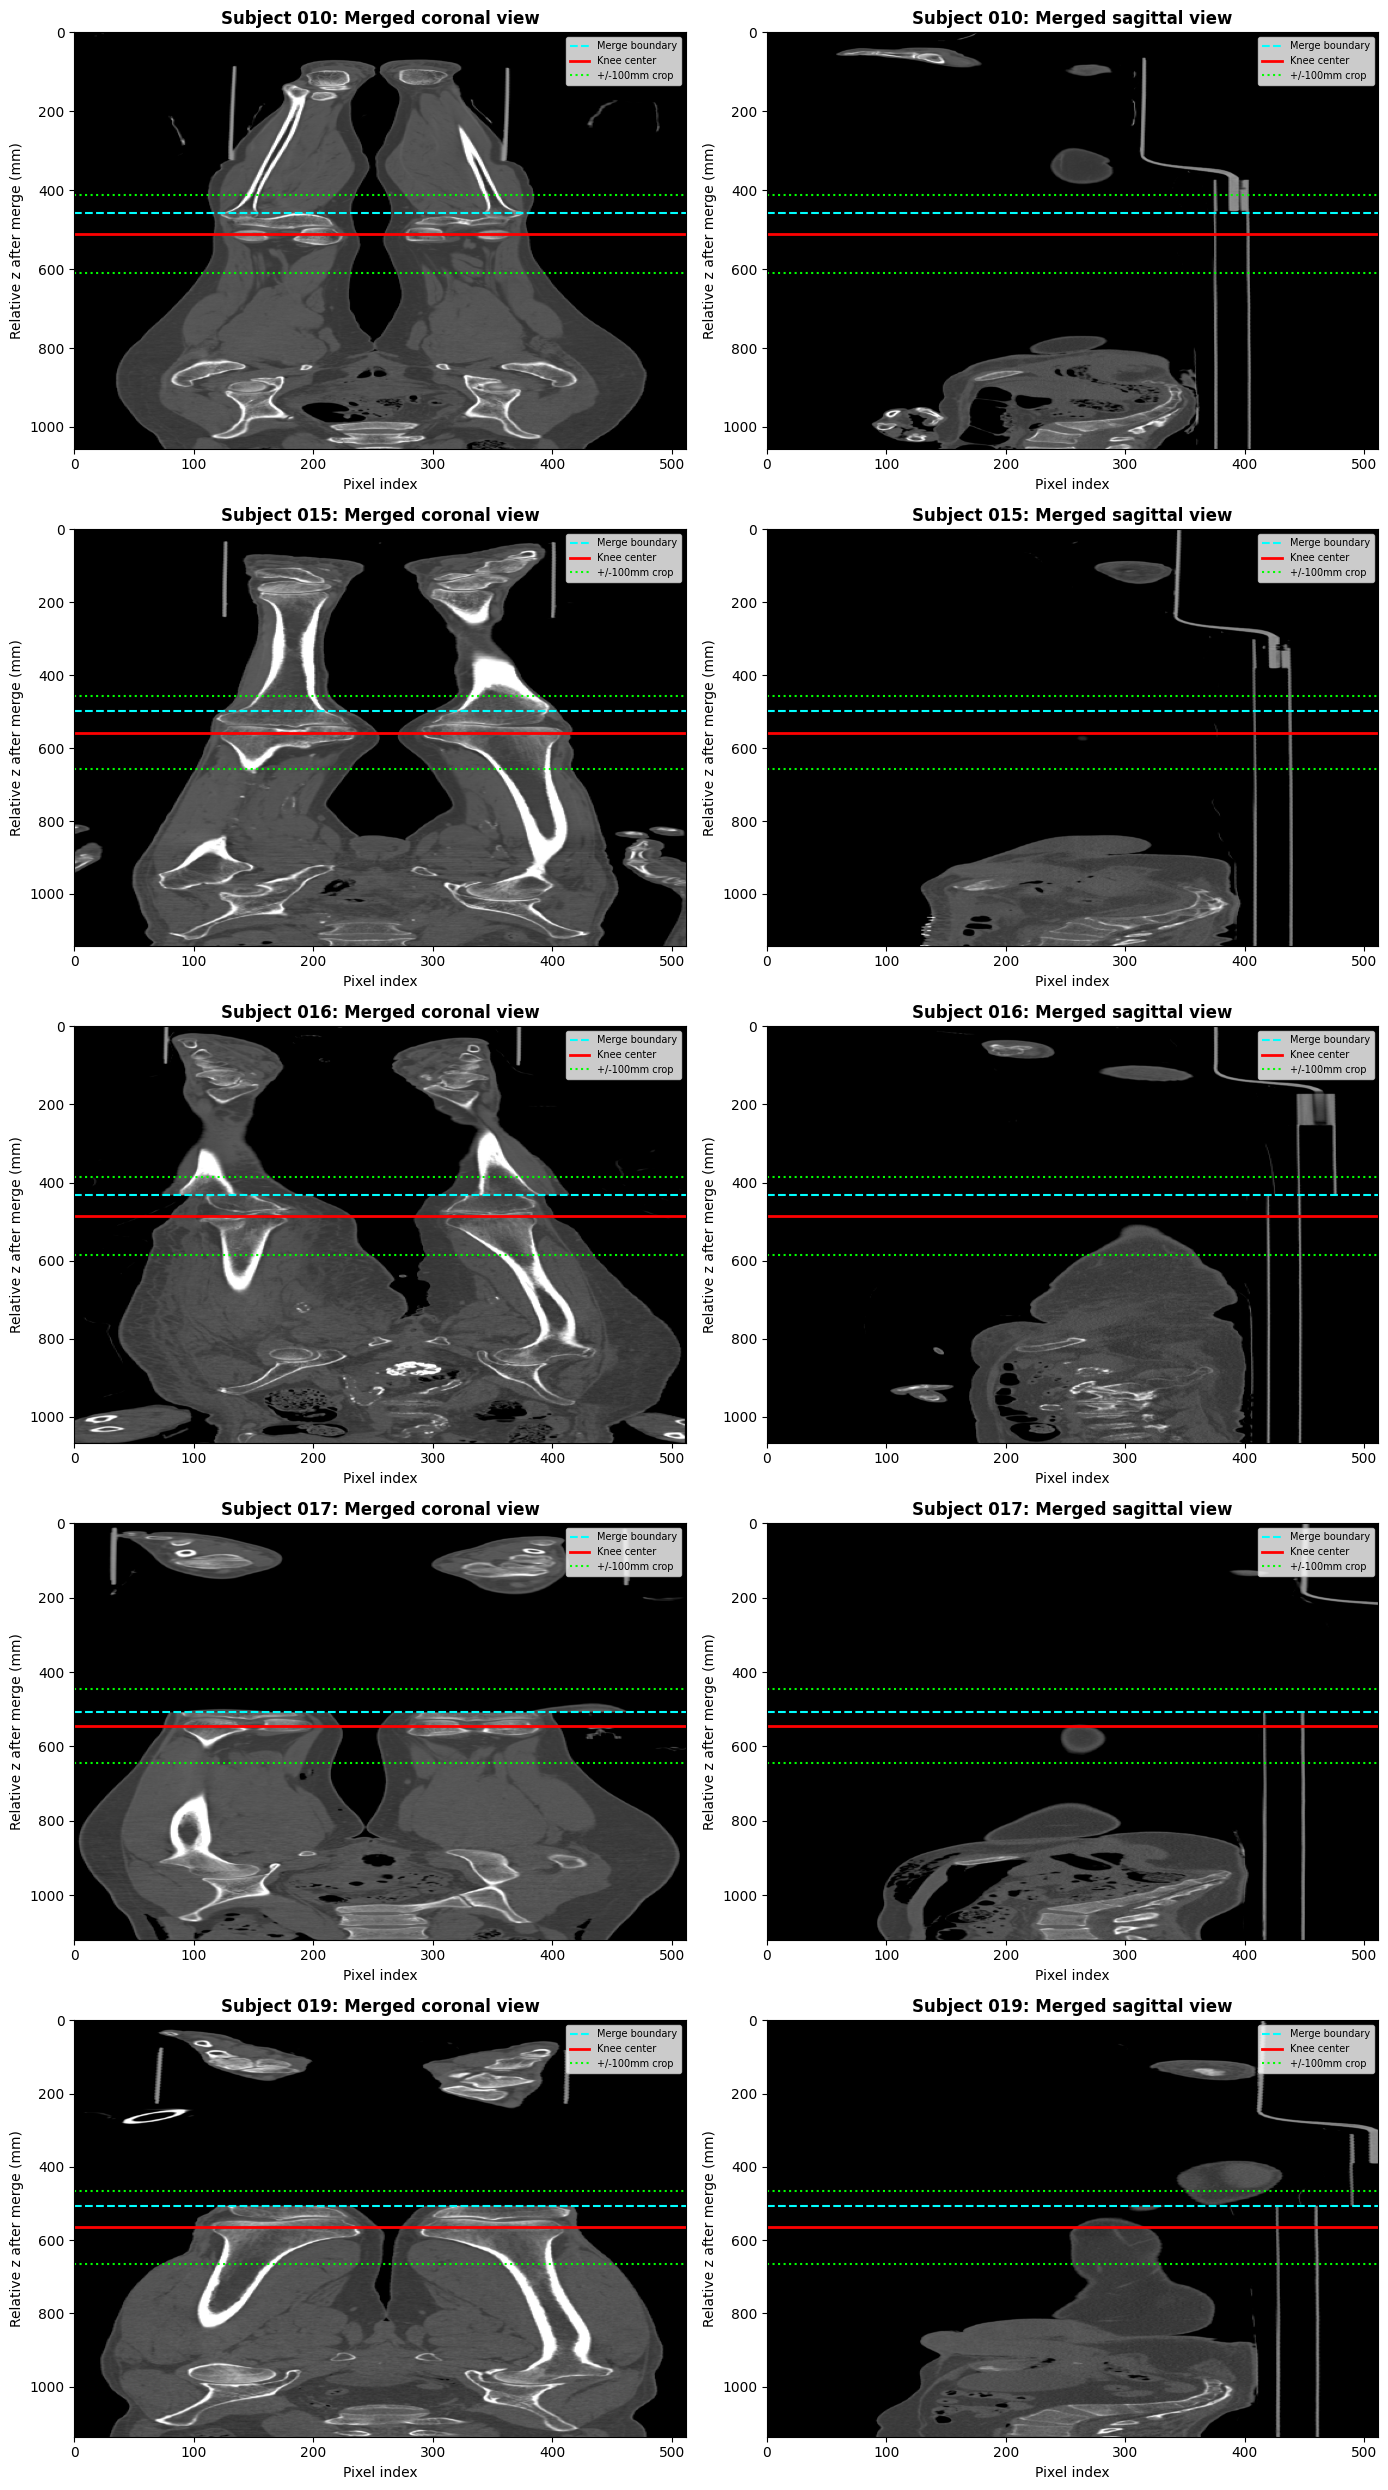

In [8]:
fig, axes = plt.subplots(len(visual_results), 2, figsize=(14, 5 * len(visual_results)))
if len(visual_results) == 1:
    axes = np.array([axes])

for row_idx, result in enumerate(visual_results):
    subject_id = result["subject"]
    span = result["merged_span_mm"]
    knee = result["knee_rel_z_mm"]

    views = [
        ("Merged coronal view", result["coronal"]),
        ("Merged sagittal view", result["sagittal"]),
    ]

    for col_idx, (title, image) in enumerate(views):
        ax = axes[row_idx, col_idx]
        ax.imshow(
            image,
            cmap="gray",
            vmin=HU_WINDOW[0],
            vmax=HU_WINDOW[1],
            aspect="auto",
            extent=[0, image.shape[1], span, 0],
        )
        for boundary in result["boundary_rel_z_mm"]:
            ax.axhline(boundary, color="cyan", linestyle="--", linewidth=1.5, label="Merge boundary")
        ax.axhline(knee, color="red", linewidth=2, label="Knee center")
        ax.axhline(knee - 100, color="lime", linestyle=":", linewidth=1.5, label="+/-100mm crop")
        ax.axhline(knee + 100, color="lime", linestyle=":", linewidth=1.5)
        ax.set_title(f"Subject {subject_id}: {title}", fontweight="bold")
        ax.set_xlabel("Pixel index")
        ax.set_ylabel("Relative z after merge (mm)")
        ax.legend(loc="upper right", fontsize=7)

plt.tight_layout()
plt.show()

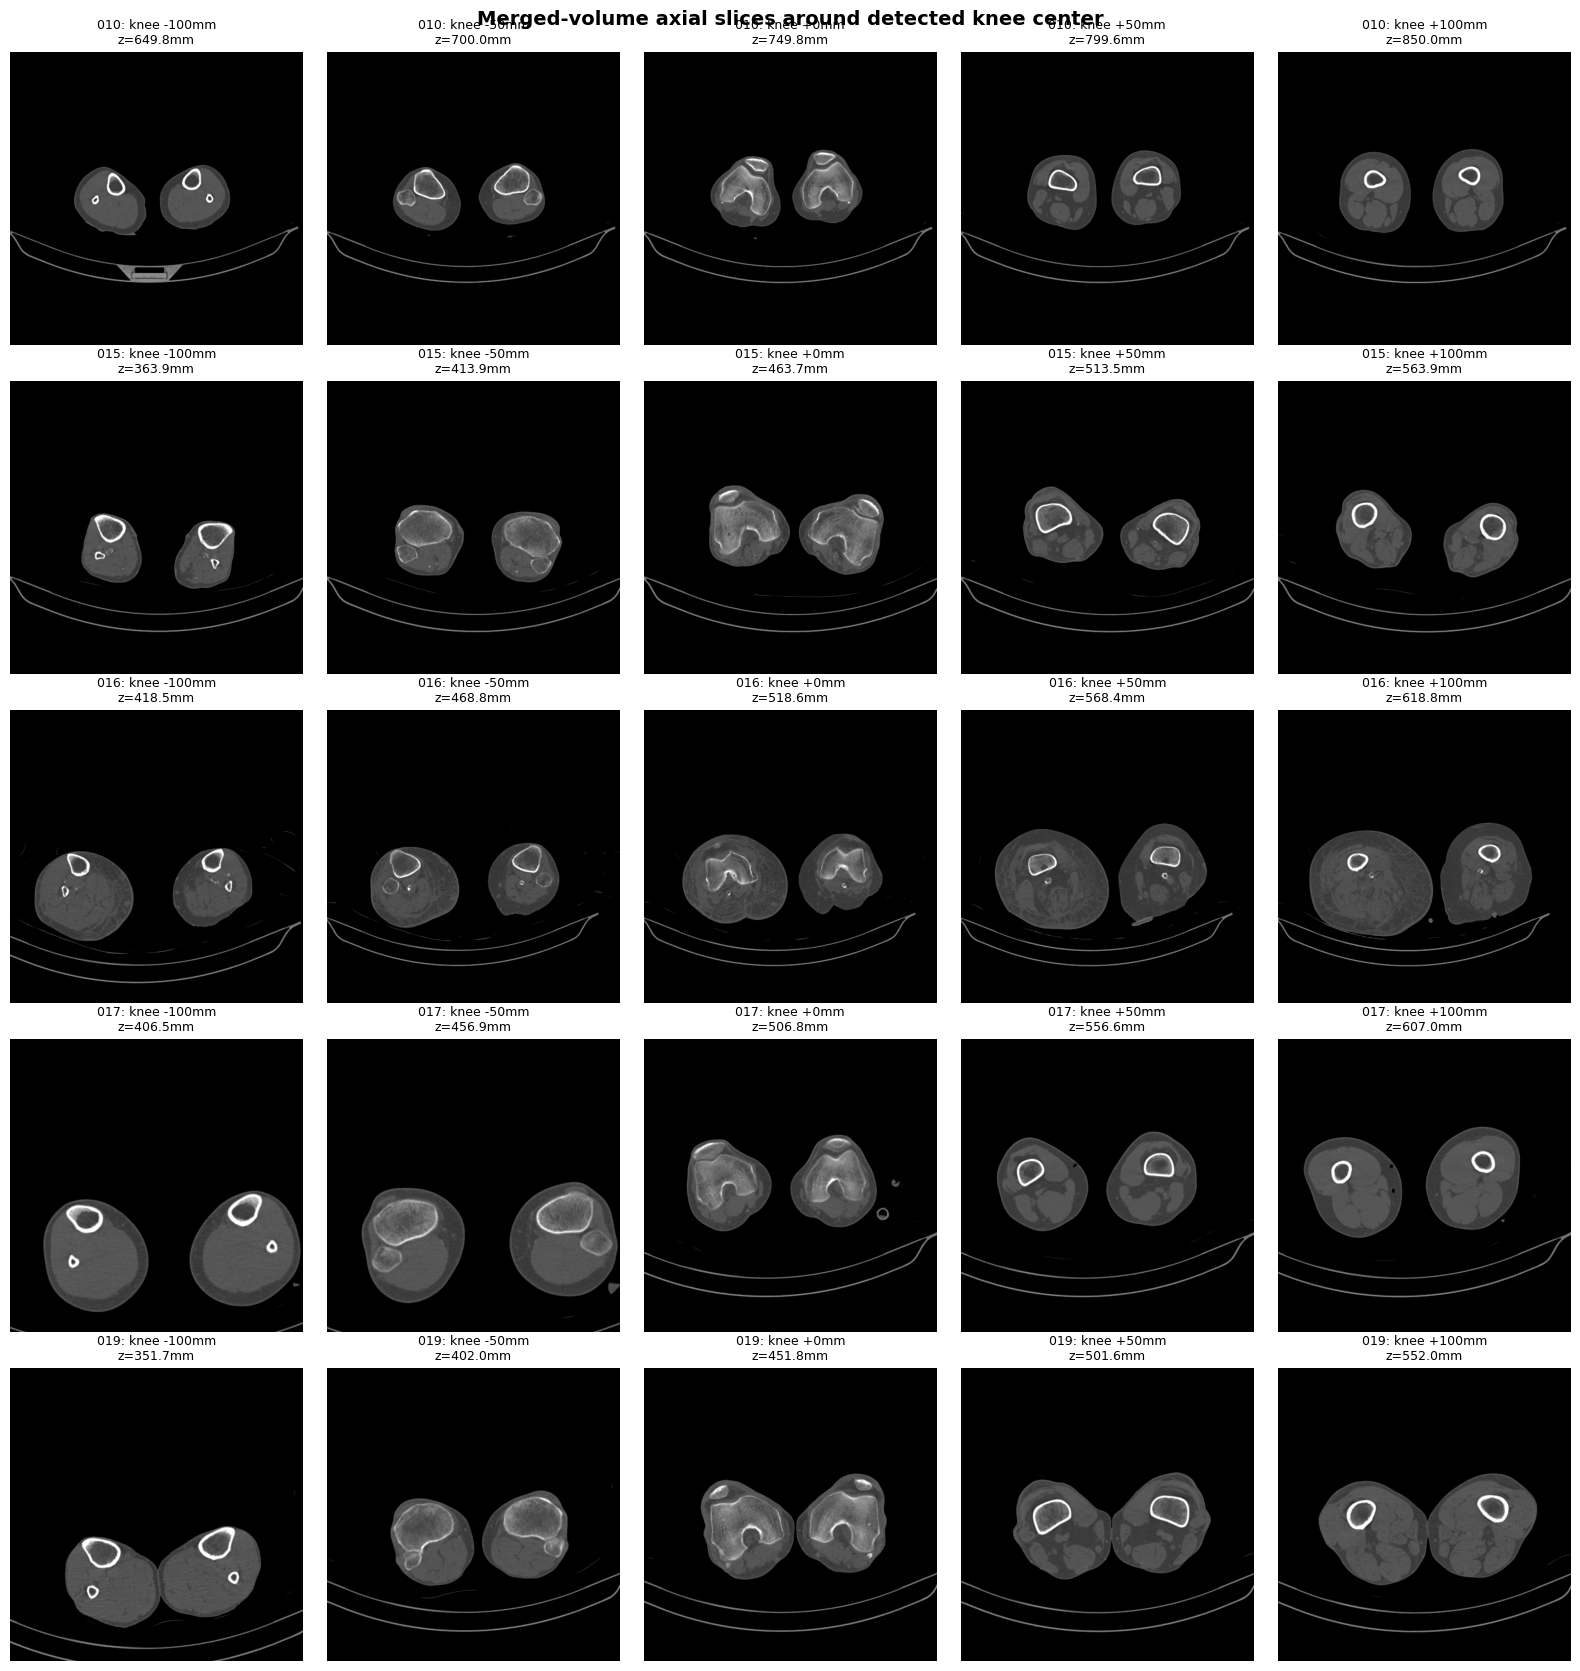

In [9]:
fig, axes = plt.subplots(len(visual_results), len(KNEE_VISUAL_OFFSETS_MM), figsize=(3.2 * len(KNEE_VISUAL_OFFSETS_MM), 3.4 * len(visual_results)))
if len(visual_results) == 1:
    axes = np.array([axes])

for row_idx, result in enumerate(visual_results):
    subject_id = result["subject"]
    for col_idx, offset in enumerate(KNEE_VISUAL_OFFSETS_MM):
        ax = axes[row_idx, col_idx]
        axial_info = result["axial_best"][offset]
        ax.imshow(axial_info["slice"], cmap="gray", vmin=HU_WINDOW[0], vmax=HU_WINDOW[1])
        ax.set_title(f"{subject_id}: knee {offset:+d}mm\nz={axial_info['actual_z']:.1f}mm", fontsize=9)
        ax.axis("off")

plt.suptitle("Merged-volume axial slices around detected knee center", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 8 - Final Inclusion Decision

In [10]:
profile_by_subject = {row["subject"]: row for row in profile_rows}
decision_rows = []
for merge_row in merge_rows:
    profile_row = profile_by_subject[merge_row["subject"]]
    usable = (
        merge_row["passes_span_check"]
        and merge_row["passes_gap_check"]
        and profile_row["has_expected_zone_knee_peak"]
    )
    decision_rows.append({
        "subject": merge_row["subject"],
        "ordered_folders_low_to_high_z": merge_row["ordered_folders_low_to_high_z"],
        "merged_span_mm_coverage": merge_row["merged_span_mm"],
        "internal_gaps_mm": merge_row["internal_gaps_mm"],
        "selected_knee_pct": profile_row["selected_knee_pct"],
        "passes_span_check": merge_row["passes_span_check"],
        "passes_gap_check": merge_row["passes_gap_check"],
        "has_expected_zone_knee_peak": profile_row["has_expected_zone_knee_peak"],
        "usable_after_merge": usable,
        "decision": "USE after merging lower + upper B30s folders" if usable else "EXCLUDE",
    })

final_cols = [
    "subject",
    "ordered_folders_low_to_high_z",
    "merged_span_mm_coverage",
    "internal_gaps_mm",
    "selected_knee_pct",
    "passes_span_check",
    "passes_gap_check",
    "has_expected_zone_knee_peak",
    "decision",
]
show_table(decision_rows, final_cols)

assert all(row["passes_span_check"] for row in decision_rows), "At least one subject failed the 700mm merged-span check."
assert all(row["passes_gap_check"] for row in decision_rows), "At least one subject has a gap larger than 5mm."
assert all(row["has_expected_zone_knee_peak"] for row in decision_rows), "At least one subject lacks an expected-zone knee peak."
assert all(row["usable_after_merge"] for row in decision_rows), "At least one subject remains unusable after merging."
assert len(visual_results) == len(SUBJECTS), "Merged anatomy visuals were not generated for every subject."

print("Conclusion:")
print(
    "Merging the lower-leg and upper-leg B30s folders makes VSD subjects "
    "010, 015, 016, 017 and 019 usable in the current workspace data. The previous "
    "exclusion of 010 and 017 should be replaced, because it was driven by "
    "an underestimated lower-leg z-span from lexicographic filename ordering, "
    "not by missing knee coverage."
)

,subject,ordered_folders_low_to_high_z,merged_span_mm_coverage,internal_gaps_mm,selected_knee_pct,passes_span_check,passes_gap_check,has_expected_zone_knee_peak,decision
0,010,268 (lower_leg) + 265 (upper_leg),1055.2,[0.4],48.4,True,True,True,USE after merging lower + upper B30s folders
1,015,453 (lower_leg) + 455 (upper_leg),1142.0,[0.2],48.9,True,True,True,USE after merging lower + upper B30s folders
2,016,481 (lower_leg) + 476 (upper_leg),1066.1,[0.5],45.5,True,True,True,USE after merging lower + upper B30s folders
3,017,490 (lower_leg) + 487 (upper_leg),1120.3,[0.1],48.7,True,True,True,USE after merging lower + upper B30s folders
4,019,497 (lower_leg) + 495 (upper_leg),1136.3,[0.5],49.7,True,True,True,USE after merging lower + upper B30s folders


Conclusion:
Merging the lower-leg and upper-leg B30s folders makes VSD subjects 010, 015, 016, 017 and 019 usable in the current workspace data. The previous exclusion of 010 and 017 should be replaced, because it was driven by an underestimated lower-leg z-span from lexicographic filename ordering, not by missing knee coverage.


## Result Summary

The validation test updates the earlier interpretation:

- `010` is usable after merging lower `268` + upper `265`.
- `015` remains usable after merging lower `453` + upper `455`.
- `016` is usable after merging lower `481` + upper `476`.
- `017` is usable after merging lower `490` + upper `487`.
- `019` is usable after merging lower `497` + upper `495`.

The merged anatomy visuals provide a direct visual check of the combined lower/upper scans before downstream knee cropping.

The root cause of the old exclusion decision for `010` and `017` is the z-span calculation, not the anatomy coverage. Future VSD multifolder screening should use all DICOM `ImagePositionPatient[2]` values or a DICOM-aware series reader order, never lexicographic first/last filenames.